In [121]:
import pandas as pd
from sklearn.model_selection import train_test_split

## **Data preparation**
- Check if the missing values are presented in the features.
- If there are missing values:
    - For caterogiral features, replace them with 'NA'
    - For numerical features, replace with with 0.0

Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use train_test_split function for that with random_state=1

In [122]:
df= pd.read_csv("course_lead_scoring.csv")

In [123]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [124]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [125]:
df[cat_cols] = df[cat_cols].fillna('NA')
df[num_cols] = df[num_cols].fillna(0.0)

In [126]:
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [127]:
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=1)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=1)

In [128]:
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (877, 9)
Validation shape: (292, 9)
Test shape: (293, 9)


## **Question 1: ROC AUC feature importance**
ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

- For each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth.
- Use the training dataset for that

If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. -df_train['balance'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

- lead_score
- number_of_courses_viewed
- interaction_count
- annual_income

In [145]:
from sklearn.metrics import roc_auc_score

y_train = train_df['converted']

num_features = ['lead_score', 'number_of_courses_viewed', 'interaction_count', 'annual_income']

auc_scores = {}

for col in num_features:
    score = train_df[col]

    auc = roc_auc_score(y_train, score)

    if auc < 0.5:
        auc = roc_auc_score(y_train, -score)
    
    auc_scores[col] = auc

for col, auc in auc_scores.items():
    print(f"{col}: {auc:.4f}")

best_feature = max(auc_scores, key=auc_scores.get)

lead_score: 0.6111
number_of_courses_viewed: 0.7652
interaction_count: 0.7272
annual_income: 0.5446


## **Question 2: Training the model**
Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.32
- 0.52
- 0.72
- 0.92

In [146]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [147]:
y_train = train_df['converted']
y_val = val_df['converted']

X_train = train_df.drop('converted', axis=1)
X_val = val_df.drop('converted', axis=1)

In [148]:
train_dict = X_train.to_dict(orient='records')
val_dict = X_val.to_dict(orient='records')

In [149]:
dv = DictVectorizer(sparse=False)

X_train_encoded = dv.fit_transform(train_dict)
X_val_encoded = dv.transform(val_dict)

In [150]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train_encoded, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [151]:
y_pred = model.predict_proba(X_val_encoded)[:, 1]

auc = roc_auc_score(y_val, y_pred)
print(f"AUC: {auc:.3f}")

AUC: 0.794


## **Question 3: Precision and Recall**
Now let's compute precision and recall for our model.

- Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
- For each threshold, compute precision and recall
- Plot them

At which threshold precision and recall curves intersect?

- 0.145
- 0.345
- 0.545
- 0.745

In [152]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.0, 1.01, 0.01)
precisions = []
recalls = []

for t in thresholds:
    y_pred_bin = (y_pred >= t)
    precisions.append(precision_score(y_val, y_pred_bin))
    recalls.append(recall_score(y_val, y_pred_bin))

c:\Users\ELITEBOOK830\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ELITEBOOK830\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


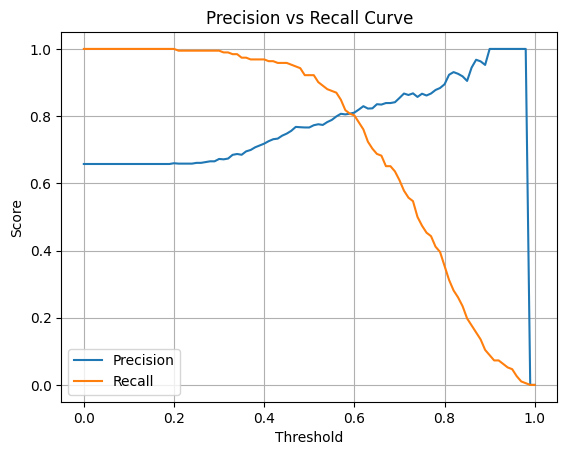

In [153]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [154]:
diff = np.abs(np.array(precisions) - np.array(recalls))

idx = diff.argmin()
best_threshold = thresholds[idx]

print(f"Precision and Recall intersect at threshold: {best_threshold:.3f}")

Precision and Recall intersect at threshold: 0.590


## **Question 4: F1 score**
Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

$$
F_1 = \frac{2 \cdot P \cdot R}{P + R}
$$


Where 
P
 is precision and 
R
 is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

- 0.14
- 0.34
- 0.54
- 0.74

In [161]:
thresholds = np.arange(0.0, 1.01, 0.01)
f1_scores = []

for t in thresholds:
    y_pred = (y_pred_bin >= t)
    p = precision_score(y_val, y_pred)
    r = recall_score(y_val, y_pred)
    if p + r == 0:
        f1 = 0
    else:
        f1 = 2 * p * r / (p + r)
    f1_scores.append(f1)


c:\Users\ELITEBOOK830\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ELITEBOOK830\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ELITEBOOK830\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [162]:
best_t = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print("Best threshold:", best_t)
print("Best F1 score:", best_f1)

Best threshold: 0.0
Best F1 score: 0.7276688453159041


## **Question 5: 5-Fold CV**
Use the KFold class from Scikit-Learn to evaluate our model on 5 different folds:

KFold(n_splits=5, shuffle=True, random_state=1)

- Iterate over different folds of df_full_train
- Split the data into train and validation
- Train the model on train with these parameters: LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
- Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?
- 0.0001
- 0.006
- 0.06
- 0.36

In [163]:
df_full_train = df.copy()

In [164]:
y = df_full_train['converted']
df_full_train = df_full_train.drop('converted', axis=1)

In [165]:
from sklearn.model_selection import KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]
    
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    train_dict = df_train.to_dict(orient='records')
    val_dict = df_val.to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(train_dict)
    X_val = dv.transform(val_dict)

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)

    y_pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_proba)
    scores.append(auc)

print("AUC per fold:", scores)
print("Mean AUC:", np.mean(scores))
print("Std dev:", np.std(scores))

AUC per fold: [0.8172202350536536, 0.7792846497764531, 0.8309278350515464, 0.8675988428158148, 0.8093413173652695]
Mean AUC: 0.8208745760125474
Std dev: 0.028845510405609943


## **Question 6: Hyperparameter Tuning**
Now let's use 5-Fold cross-validation to find the best parameter C

- Iterate over the following C values: [0.000001, 0.001, 1]
- Initialize KFold with the same parameters as previously
- Use these parameters for the model: LogisticRegression(solver='liblinear', C=C, max_iter=1000)
- Compute the mean score as well as the std (round the mean and std to 3 decimal digits)

Which C leads to the best mean score?
- 0.000001
- 0.001
- 1

If you have ties, select the score with the lowest std. If you still have ties, select the smallest C.

In [166]:
C_values = [0.000001, 0.001, 1]
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

for C in C_values:
    scores = []
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        train_dict = df_train.to_dict(orient='records')
        val_dict = df_val.to_dict(orient='records')

        dv = DictVectorizer(sparse=False)
        X_train = dv.fit_transform(train_dict)
        X_val = dv.transform(val_dict)

        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train, y_train)

        y_pred_proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred_proba)
        scores.append(auc)

    print(f"C={C}")
    print(f"  Mean AUC: {np.mean(scores):.3f}")
    print(f"  Std AUC:  {np.std(scores):.3f}")
    print("----------------------")

C=1e-06
  Mean AUC: 0.549
  Std AUC:  0.030
----------------------
C=0.001
  Mean AUC: 0.862
  Std AUC:  0.024
----------------------
C=1
  Mean AUC: 0.821
  Std AUC:  0.029
----------------------
